# 📊 EduNilai — Exploratory Data Analysis (EDA)

**Project:** EduNilai — *"You paid for a degree. Did it pay you back?"*
**Stage:** 02 — Exploratory Data Analysis
**SDGs:** SDG 4 (Quality Education) + SDG 8 (Decent Work & Economic Growth)

---

## 🗺️ EDA Roadmap

This notebook explores all collected datasets across five themes:

| # | Theme | Key Question |
|---|---|---|
| A | Tuition Fees | How large is the public vs private cost gap? |
| B | CPI-Adjusted Real Cost | How much has the real cost of a degree risen since 2010? |
| C | Graduate Underemployment | Are graduates increasingly stuck in low-skill jobs? |
| D | Gender & Demographic Gaps | Does the same degree pay back equally for everyone? |
| E | ASEAN Benchmarking | How does Malaysia compare to regional peers? |

> This is an **exploratory** notebook. Deep analysis and ROI calculations are in `03_analysis.ipynb`.


## ⚙️ Setup — Load All Datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'

# ── Load all datasets ─────────────────────────────────────────────────
fees_mean  = pd.read_csv('../data/cleaned/fees_mean.csv')
fees_raw   = pd.read_csv('../data/cleaned/fees_raw.csv')
cpi        = pd.read_csv('../data/cleaned/cpi.csv', parse_dates=['date'])
lfs        = pd.read_csv('../data/cleaned/lfs_annual_sex.csv', parse_dates=['date'])
sru_age    = pd.read_csv('../data/cleaned/graduate_underemployment_age.csv', parse_dates=['date'])
sru_sex    = pd.read_csv('../data/cleaned/graduate_underemployment_sex.csv', parse_dates=['date'])
youth      = pd.read_csv('../data/cleaned/youth_unemployment_monthly.csv', parse_dates=['date'])
hh_nat     = pd.read_csv('../data/cleaned/hh_income_national.csv', parse_dates=['date'])
hh_state   = pd.read_csv('../data/cleaned/hh_income_state.csv', parse_dates=['date'])
gini       = pd.read_csv('../data/cleaned/income_inequality_gini.csv', parse_dates=['date'])
asean      = pd.read_csv('../data/cleaned/asean_comparison.csv')

print("All datasets loaded.")
for name, df in [('fees_mean', fees_mean), ('fees_raw', fees_raw), ('cpi', cpi),
                 ('lfs', lfs), ('sru_age', sru_age), ('sru_sex', sru_sex),
                 ('youth', youth), ('hh_nat', hh_nat), ('hh_state', hh_state),
                 ('gini', gini), ('asean', asean)]:
    print(f"  {name:12s}: {df.shape}")


All datasets loaded.
  fees_mean   : (11, 7)
  fees_raw    : (186, 5)
  cpi         : (224, 3)
  lfs         : (42, 9)
  sru_age     : (175, 4)
  sru_sex     : (105, 4)
  youth       : (120, 5)
  hh_nat      : (6, 3)
  hh_state    : (96, 4)
  gini        : (5, 2)
  asean       : (140, 8)


---
## 🎓 A. Tuition Fees — Public vs Private Cost Gap

**Data:** `fees_mean.csv`, `fees_raw.csv`
**Key question:** How much more does a private degree cost compared to a public one — and does it vary by field?


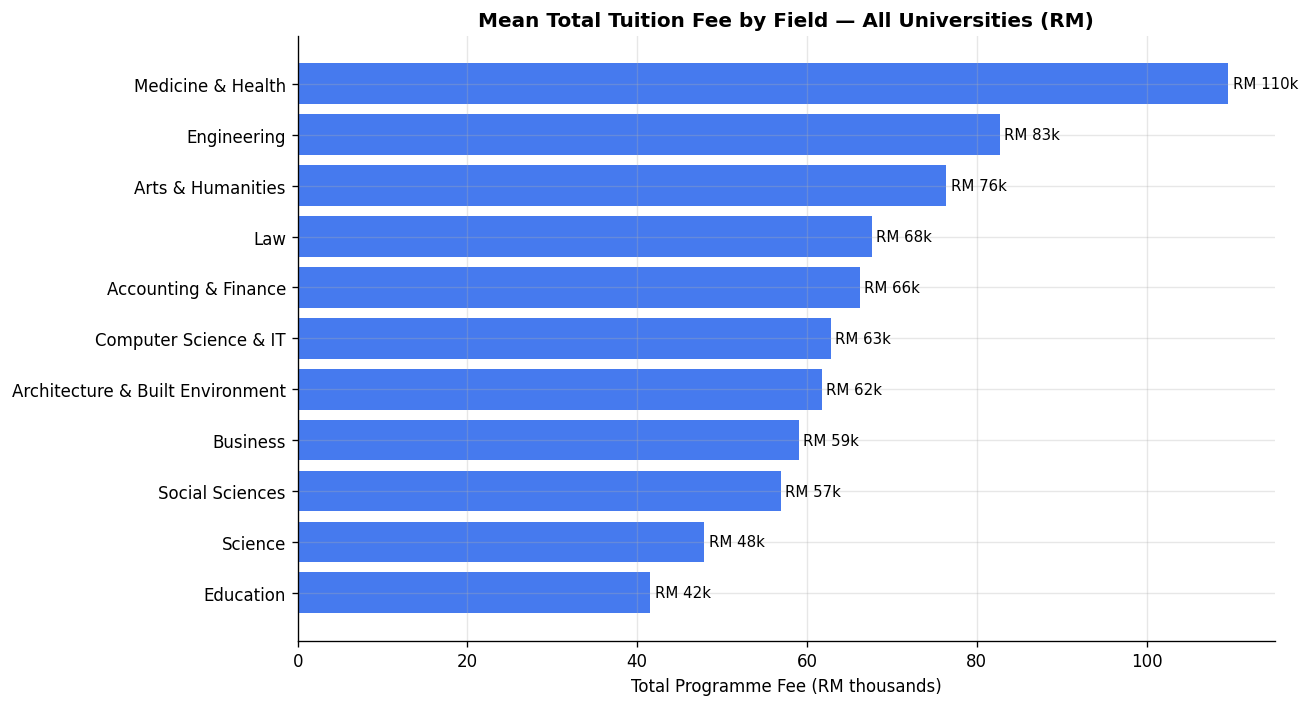

Mean fees by field:
                  field_category  Overall_Mean_RM
               Medicine & Health        109638.50
                     Engineering         82716.25
               Arts & Humanities         76426.68
                             Law         67617.50
            Accounting & Finance         66233.54
           Computer Science & IT         62805.00
Architecture & Built Environment         61747.50
                        Business         59020.72
                 Social Sciences         56946.67
                         Science         47905.56
                       Education         41559.44


In [2]:
# ── A1: Overall mean fee by field (sorted) ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

df_plot = fees_mean.sort_values('Overall_Mean_RM', ascending=True)
bars = ax.barh(df_plot['field_category'], df_plot['Overall_Mean_RM'] / 1000,
               color=BLUE, alpha=0.85)
ax.set_xlabel('Total Programme Fee (RM thousands)')
ax.set_title('Mean Total Tuition Fee by Field — All Universities (RM)', fontweight='bold')

for bar, val in zip(bars, df_plot['Overall_Mean_RM']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'RM {val/1000:.0f}k', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Mean fees by field:")
print(fees_mean[['field_category','Overall_Mean_RM']].sort_values('Overall_Mean_RM', ascending=False).to_string(index=False))


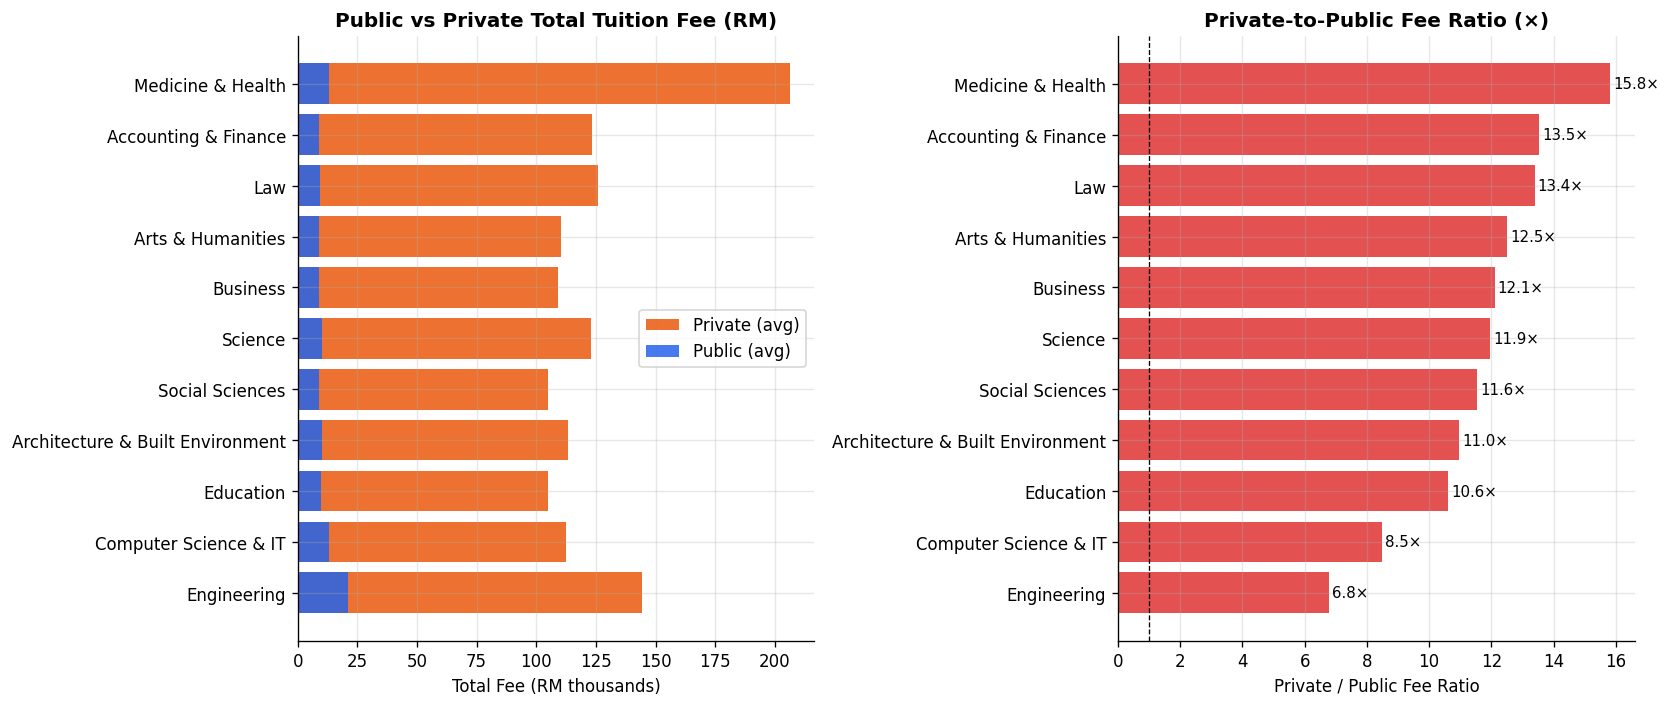


Public vs Private gap:
                  field_category  public_avg  private_avg  gap_ratio
                     Engineering   21300.000   144132.500   6.766784
           Computer Science & IT   13245.000   112365.000   8.483579
                       Education    9896.665   104885.000  10.598015
Architecture & Built Environment   10322.500   113172.500  10.963672
                 Social Sciences    9073.335   104820.000  11.552533
                         Science   10305.000   123106.670  11.946305
                        Business    9010.000   109031.430  12.101158
               Arts & Humanities    8808.700   110235.665  12.514408
                             Law    9400.000   125835.000  13.386702
            Accounting & Finance    9114.165   123352.915  13.534198
               Medicine & Health   13040.000   206237.000  15.815721


In [3]:
# ── A2: Public vs Private gap by field ───────────────────────────────
# Public = UTM + UM average, Private = APU + Taylor's average
fees_mean['public_avg']  = fees_mean[['UTM', 'UM']].mean(axis=1)
fees_mean['private_avg'] = fees_mean[["APU", "Taylor's"]].mean(axis=1)
fees_mean['gap_ratio']   = fees_mean['private_avg'] / fees_mean['public_avg']

df_gap = fees_mean.dropna(subset=['public_avg', 'private_avg']).sort_values('gap_ratio', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute gap
x = range(len(df_gap))
axes[0].barh(df_gap['field_category'], df_gap['private_avg'] / 1000,
             label='Private (avg)', color=ORANGE, alpha=0.85)
axes[0].barh(df_gap['field_category'], df_gap['public_avg'] / 1000,
             label='Public (avg)', color=BLUE, alpha=0.85)
axes[0].set_xlabel('Total Fee (RM thousands)')
axes[0].set_title('Public vs Private Total Tuition Fee (RM)', fontweight='bold')
axes[0].legend()

# Gap ratio
axes[1].barh(df_gap['field_category'], df_gap['gap_ratio'], color=RED, alpha=0.8)
axes[1].axvline(1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Private / Public Fee Ratio')
axes[1].set_title('Private-to-Public Fee Ratio (×)', fontweight='bold')
for i, (_, row) in enumerate(df_gap.iterrows()):
    axes[1].text(row['gap_ratio'] + 0.1, i, f'{row["gap_ratio"]:.1f}×', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nPublic vs Private gap:")
print(df_gap[['field_category','public_avg','private_avg','gap_ratio']].to_string(index=False))


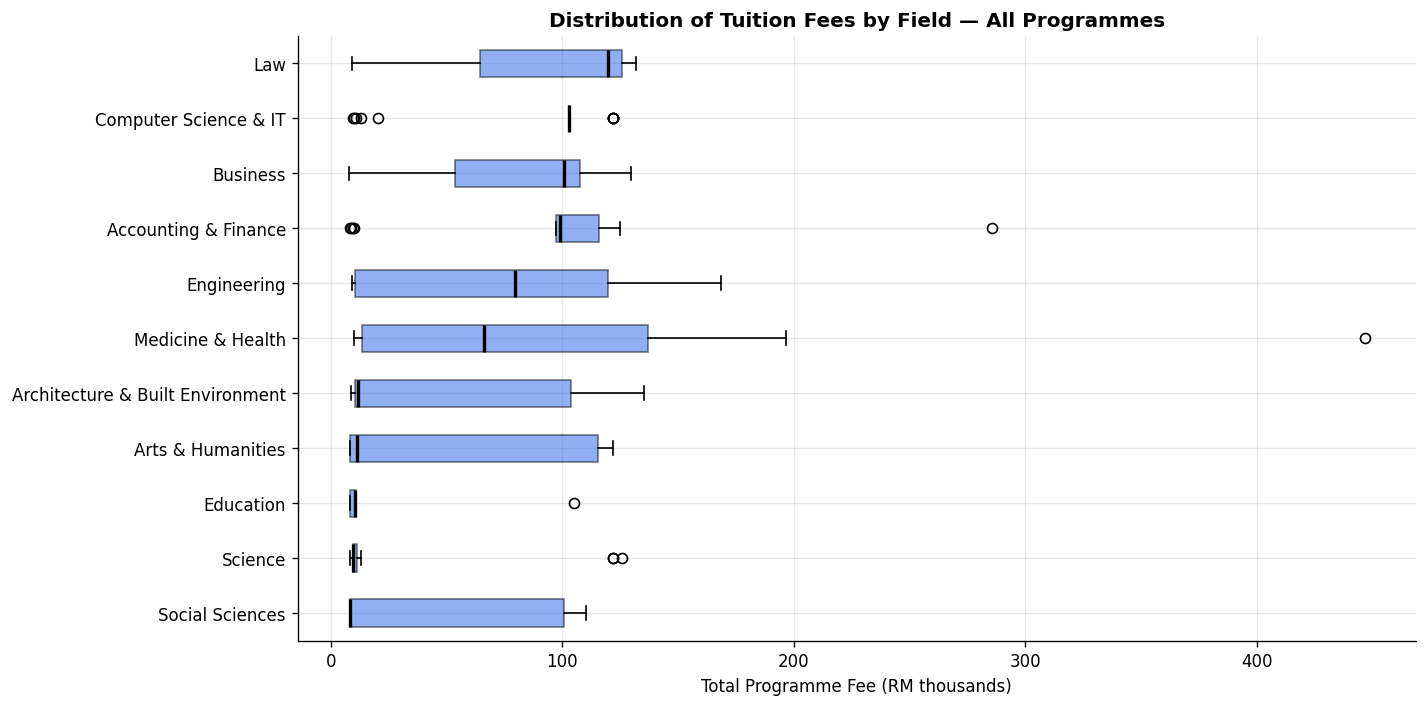

In [4]:
# ── A3: Raw fee distribution — spread within each field ──────────────
fig, ax = plt.subplots(figsize=(12, 6))

fields_order = fees_raw.groupby('field_category')['total_fee'].median().sort_values().index

fee_data = [fees_raw[fees_raw['field_category'] == f]['total_fee'].dropna().values / 1000
            for f in fields_order]

bp = ax.boxplot(fee_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.5),
                medianprops=dict(color='black', linewidth=2))
ax.set_yticklabels(fields_order)
ax.set_xlabel('Total Programme Fee (RM thousands)')
ax.set_title('Distribution of Tuition Fees by Field — All Programmes', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📈 B. CPI-Adjusted Real Cost of a Degree

**Data:** `cpi.csv`, `fees-mean.csv`
**Key question:** After adjusting for inflation, how much more expensive is a degree today than in 2010?

We use the **Education CPI (division 10)** to deflate fee values, and **Overall CPI** for general purchasing power context.


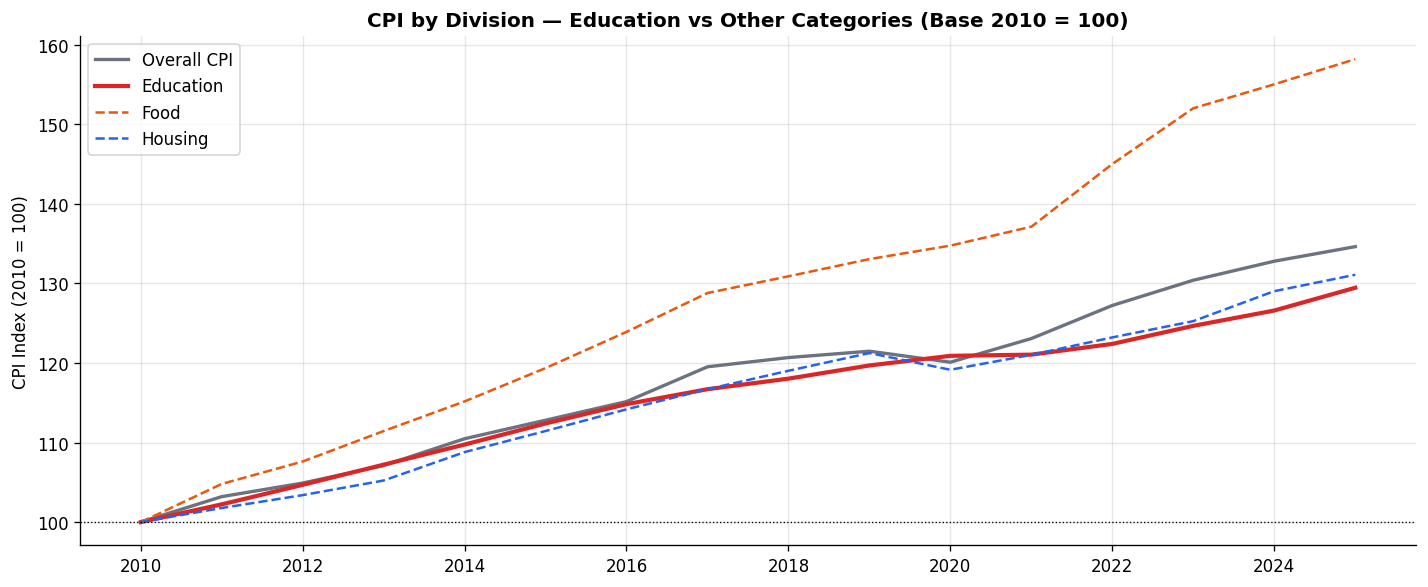

Education CPI (division 10):
      date      index
2010-01-01 100.000000
2011-01-01 102.233333
2012-01-01 104.683333
2013-01-01 107.225000
2014-01-01 109.750000
2015-01-01 112.400000
2016-01-01 114.825000
2017-01-01 116.708333
2018-01-01 118.033333
2019-01-01 119.691667
2020-01-01 120.900000
2021-01-01 121.050000
2022-01-01 122.400000
2023-01-01 124.666667
2024-01-01 126.591667
2025-01-01 129.458333


In [5]:
# ── B1: Education CPI vs Overall CPI trend ───────────────────────────
cpi_overall = cpi[cpi['division'] == 'overall'].copy()
cpi_edu     = cpi[cpi['division'] == '10'].copy()   # 10 = Education
cpi_food    = cpi[cpi['division'] == '01'].copy()   # 01 = Food
cpi_housing = cpi[cpi['division'] == '04'].copy()   # 04 = Housing

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cpi_overall['date'], cpi_overall['index'], label='Overall CPI',  color=GRAY,   linewidth=2)
ax.plot(cpi_edu['date'],     cpi_edu['index'],     label='Education',     color=RED,    linewidth=2.5)
ax.plot(cpi_food['date'],    cpi_food['index'],    label='Food',          color=ORANGE, linewidth=1.5, linestyle='--')
ax.plot(cpi_housing['date'], cpi_housing['index'], label='Housing',       color=BLUE,   linewidth=1.5, linestyle='--')
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title('CPI by Division — Education vs Other Categories (Base 2010 = 100)', fontweight='bold')
ax.set_ylabel('CPI Index (2010 = 100)')
ax.legend()
plt.tight_layout()
plt.show()

# Print education CPI values
print("Education CPI (division 10):")
print(cpi_edu[['date','index']].to_string(index=False))


Education CPI 2010: 100.00
Education CPI 2025: 129.46
Deflation factor: 0.7724
=> Fees today are 1.29x more expensive in nominal terms than 2010


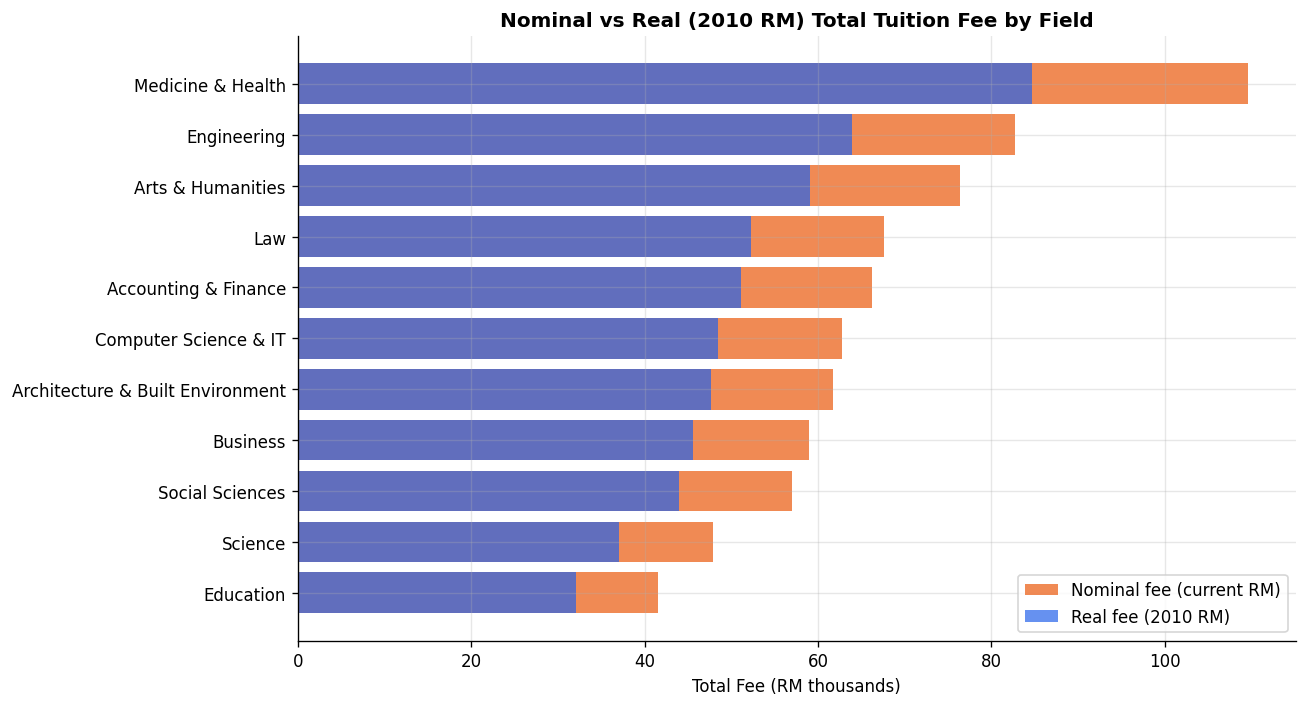

In [6]:
# ── B2: CPI-adjusted real fee in 2010 RM ─────────────────────────────
# If a degree costs X today, what is that in 2010 purchasing power?
# Real cost (2010 RM) = Nominal fee × (CPI_2010 / CPI_current)

cpi_edu_2010   = cpi_edu[cpi_edu['date'].dt.year == 2010]['index'].values[0]
cpi_edu_latest = cpi_edu[cpi_edu['date'].dt.year == cpi_edu['date'].dt.year.max()]['index'].values[0]

deflation_factor = cpi_edu_2010 / cpi_edu_latest
print(f"Education CPI 2010: {cpi_edu_2010:.2f}")
print(f"Education CPI {cpi_edu['date'].dt.year.max()}: {cpi_edu_latest:.2f}")
print(f"Deflation factor: {deflation_factor:.4f}")
print(f"=> Fees today are {cpi_edu_latest/cpi_edu_2010:.2f}x more expensive in nominal terms than 2010")

fees_mean['real_fee_2010rm'] = fees_mean['Overall_Mean_RM'] * deflation_factor
fees_mean['real_public_2010rm']  = fees_mean['public_avg']  * deflation_factor
fees_mean['real_private_2010rm'] = fees_mean['private_avg'] * deflation_factor

fig, ax = plt.subplots(figsize=(11, 6))
df_plot = fees_mean.sort_values('Overall_Mean_RM', ascending=True)
ax.barh(df_plot['field_category'], df_plot['Overall_Mean_RM'] / 1000,
        label='Nominal fee (current RM)', color=ORANGE, alpha=0.7)
ax.barh(df_plot['field_category'], df_plot['real_fee_2010rm'] / 1000,
        label='Real fee (2010 RM)', color=BLUE, alpha=0.7)
ax.set_xlabel('Total Fee (RM thousands)')
ax.set_title('Nominal vs Real (2010 RM) Total Tuition Fee by Field', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


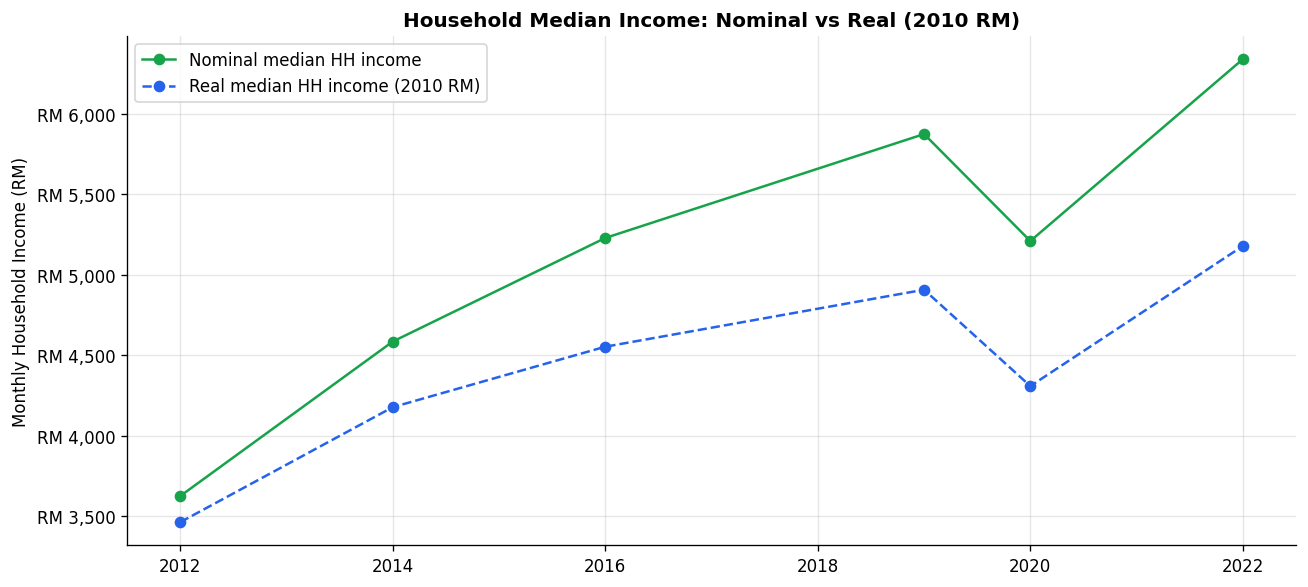


Key: Real income growth vs education cost inflation
  Median HH income 2012: RM 3,626
  Median HH income 2022: RM 6,338
  Income growth 2012-2022: +74.8%
  Education CPI growth 2012-2022: +16.9%


In [7]:
# ── B3: How household income kept up with education inflation ─────────
# Merge HH income with education CPI on year
hh = hh_nat.copy()
hh['year'] = hh['date'].dt.year
cpi_edu['year'] = cpi_edu['date'].dt.year

merged = hh.merge(cpi_edu[['year','index']].rename(columns={'index':'edu_cpi'}), on='year')
merged['real_median_income_2010rm'] = merged['income_median'] * (cpi_edu_2010 / merged['edu_cpi'])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(merged['year'], merged['income_median'],           marker='o', color=GREEN,  label='Nominal median HH income')
ax.plot(merged['year'], merged['real_median_income_2010rm'], marker='o', color=BLUE, linestyle='--', label='Real median HH income (2010 RM)')
ax.set_title('Household Median Income: Nominal vs Real (2010 RM)', fontweight='bold')
ax.set_ylabel('Monthly Household Income (RM)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print("\nKey: Real income growth vs education cost inflation")
print(f"  Median HH income 2012: RM {merged[merged['year']==2012]['income_median'].values[0]:,}")
print(f"  Median HH income 2022: RM {merged[merged['year']==2022]['income_median'].values[0]:,}")
pct_income = (merged[merged['year']==2022]['income_median'].values[0] / merged[merged['year']==2012]['income_median'].values[0] - 1) * 100
pct_edu_cpi = (merged[merged['year']==2022]['edu_cpi'].values[0] / merged[merged['year']==2012]['edu_cpi'].values[0] - 1) * 100
print(f"  Income growth 2012-2022: +{pct_income:.1f}%")
print(f"  Education CPI growth 2012-2022: +{pct_edu_cpi:.1f}%")


---
## 👷 C. Graduate Underemployment (Skills-Related Underemployment)

**Data:** `graduate_underemployment_age.csv`, `graduate_underemployment_sex.csv`, `youth_unemployment_monthly.csv`, `lfs_annual_sex.csv`
**Key question:** Are graduates increasingly stuck in jobs that don't require their degree?

SRU (Skills-Related Underemployment) = degree holder working in a semi-skilled or low-skilled job.


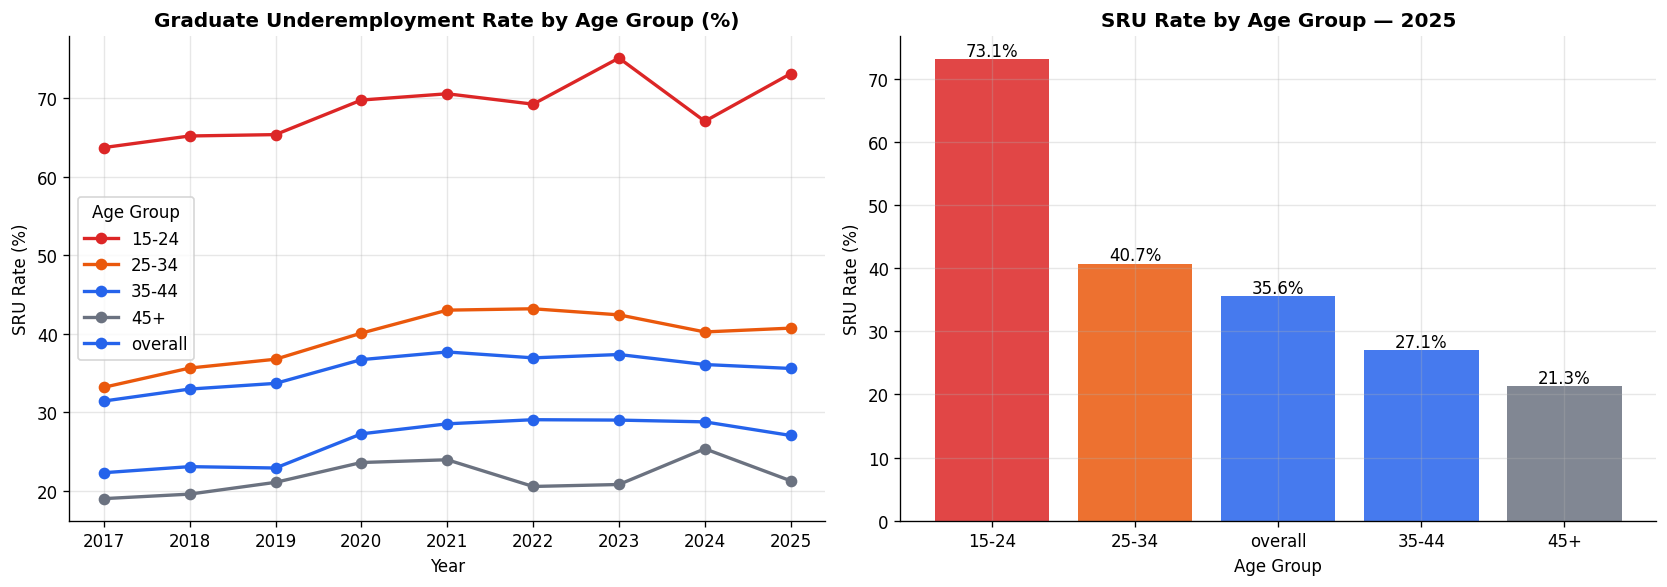

In [8]:
# ── C1: SRU rate trend by age group ──────────────────────────────────
# Annual average (data is quarterly)
sru_age['year'] = sru_age['date'].dt.year
sru_annual = sru_age.groupby(['year','age'])[['sru_rate','sru_persons']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_colors = {'15-24': RED, '25-34': ORANGE, '35-44': BLUE, '45+': GRAY}
for age, grp in sru_annual.groupby('age'):
    axes[0].plot(grp['year'], grp['sru_rate'], marker='o',
                 label=age, color=age_colors.get(age, BLUE), linewidth=2)
axes[0].set_title('Graduate Underemployment Rate by Age Group (%)', fontweight='bold')
axes[0].set_ylabel('SRU Rate (%)')
axes[0].set_xlabel('Year')
axes[0].legend(title='Age Group')

# Latest year bar
latest_year = sru_annual['year'].max()
df_lat = sru_annual[sru_annual['year'] == latest_year].sort_values('sru_rate', ascending=False)
bars = axes[1].bar(df_lat['age'], df_lat['sru_rate'],
                   color=[age_colors.get(a, BLUE) for a in df_lat['age']], alpha=0.85)
axes[1].set_title(f'SRU Rate by Age Group — {latest_year}', fontweight='bold')
axes[1].set_ylabel('SRU Rate (%)')
axes[1].set_xlabel('Age Group')
for bar, val in zip(bars, df_lat['sru_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


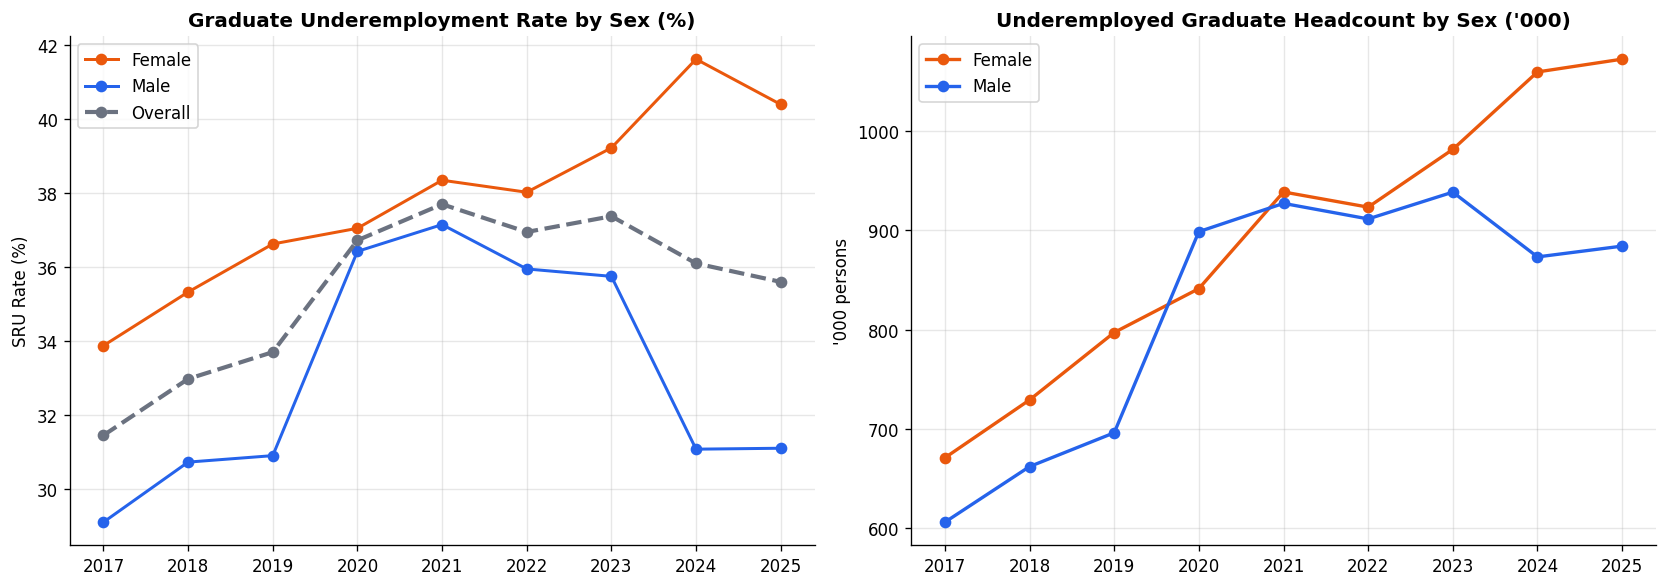

In [12]:
# ── C2: SRU rate by sex ───────────────────────────────────────────────
sru_sex['year'] = sru_sex['date'].dt.year
sru_sex_annual = sru_sex.groupby(['year','sex'])[['sru_rate','sru_persons']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_colors = {'female': ORANGE, 'male': BLUE, 'overall': GRAY}
for sex, grp in sru_sex_annual.groupby('sex'):
    lw = 2.5 if sex == 'overall' else 1.8
    ls = '--' if sex == 'overall' else '-'
    axes[0].plot(grp['year'], grp['sru_rate'], marker='o',
                 label=sex.title(), color=sex_colors.get(sex, GRAY),
                 linewidth=lw, linestyle=ls)
axes[0].set_title('Graduate Underemployment Rate by Sex (%)', fontweight='bold')
axes[0].set_ylabel('SRU Rate (%)')
axes[0].legend()

# Headcount
for sex, grp in sru_sex_annual[sru_sex_annual['sex'] != 'overall'].groupby('sex'):
    axes[1].plot(grp['year'], grp['sru_persons'], marker='o',
                 label=sex.title(), color=sex_colors.get(sex, GRAY), linewidth=2)
axes[1].set_title("Underemployed Graduate Headcount by Sex ('000)", fontweight='bold')
axes[1].set_ylabel("'000 persons")
axes[1].legend()

plt.tight_layout()
plt.show()


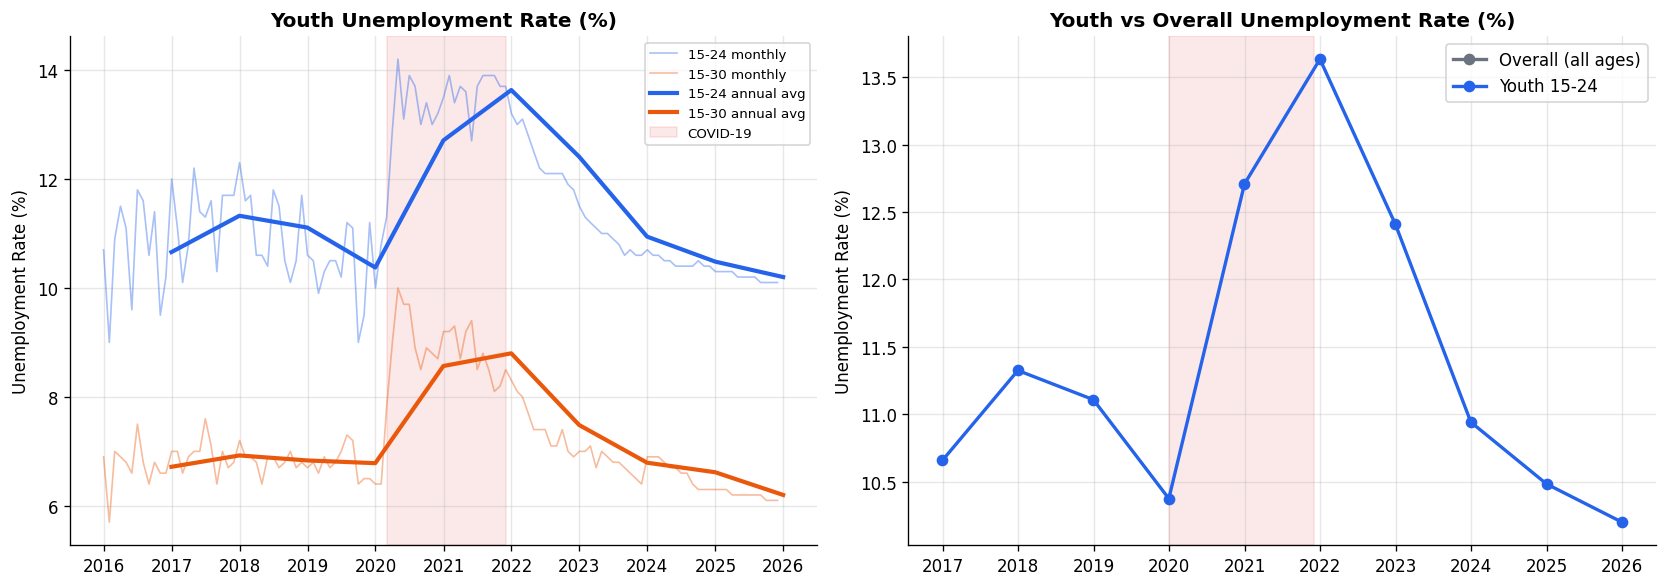

In [13]:
# ── C3: Youth unemployment trend ─────────────────────────────────────
youth_annual = youth.set_index('date').resample('A').mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly + annual average
axes[0].plot(youth['date'], youth['u_rate_15_24'], color=BLUE,
             alpha=0.4, linewidth=1, label='15-24 monthly')
axes[0].plot(youth['date'], youth['u_rate_15_30'], color=ORANGE,
             alpha=0.4, linewidth=1, label='15-30 monthly')
axes[0].plot(youth_annual['date'], youth_annual['u_rate_15_24'],
             color=BLUE, linewidth=2.5, label='15-24 annual avg')
axes[0].plot(youth_annual['date'], youth_annual['u_rate_15_30'],
             color=ORANGE, linewidth=2.5, label='15-30 annual avg')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
                alpha=0.1, color=RED, label='COVID-19')
axes[0].set_title('Youth Unemployment Rate (%)', fontweight='bold')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].legend(fontsize=8)

# Overall unemployment (all ages) from LFS for comparison
lfs_both = lfs[lfs['sex'] == 'both'].copy()
axes[1].plot(lfs_both['date'], lfs_both['u_rate'], marker='o',
             color=GRAY, linewidth=2, label='Overall (all ages)')
axes[1].plot(youth_annual['date'], youth_annual['u_rate_15_24'],
             marker='o', color=BLUE, linewidth=2, label='Youth 15-24')
axes[1].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-01'),
                alpha=0.1, color=RED)
axes[1].set_title('Youth vs Overall Unemployment Rate (%)', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 👥 D. Gender & Demographic Gaps

**Data:** `lfs_annual_sex.csv`, `hh_income_national.csv`, `hh_income_state.csv`, `income_inequality_gini.csv`
**Key question:** Does the same degree pay back equally for men and women, and across different states?


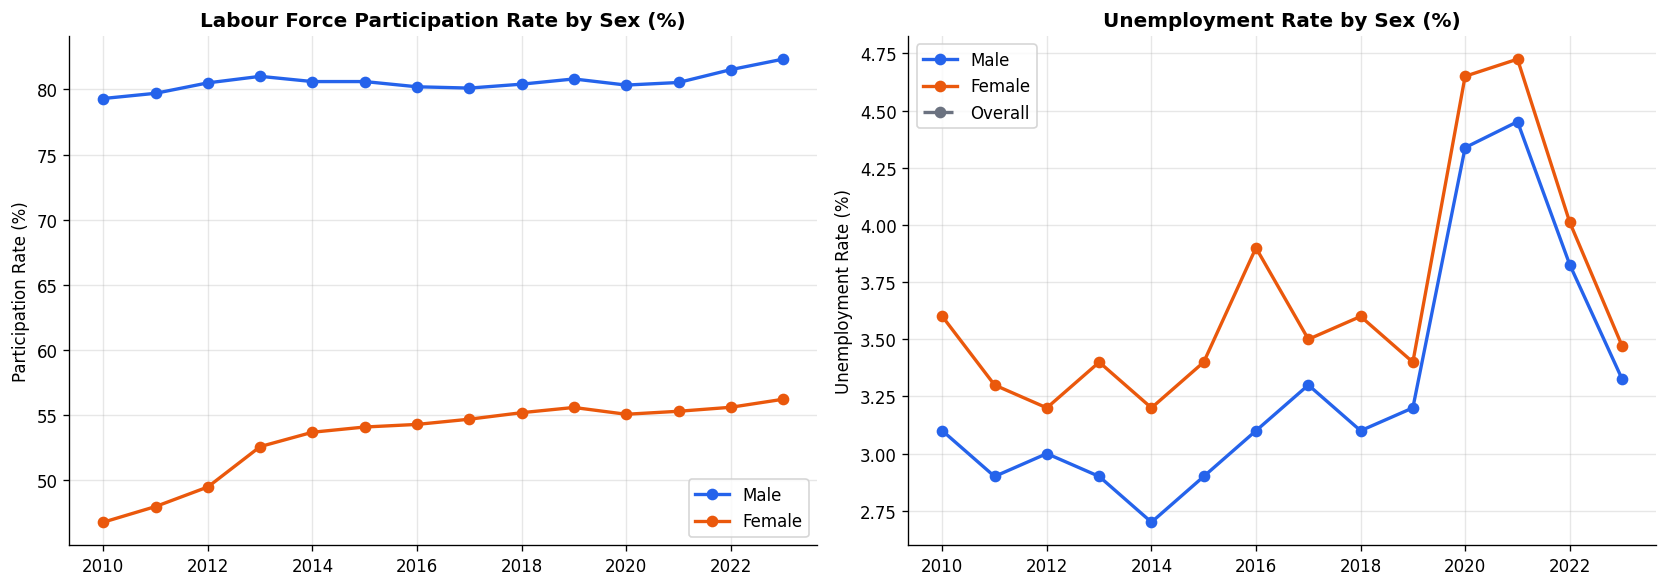

Latest year participation gap: Male 82.3% vs Female 56.2% => Gap = 26.1 pp


In [14]:
# ── D1: Labour force participation rate by sex ───────────────────────
lfs_m = lfs[lfs['sex'] == 'male'].copy()
lfs_f = lfs[lfs['sex'] == 'female'].copy()
lfs_b = lfs[lfs['sex'] == 'both'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lfs_m['date'], lfs_m['p_rate'], marker='o', color=BLUE,   label='Male',   linewidth=2)
axes[0].plot(lfs_f['date'], lfs_f['p_rate'], marker='o', color=ORANGE, label='Female', linewidth=2)
axes[0].set_title('Labour Force Participation Rate by Sex (%)', fontweight='bold')
axes[0].set_ylabel('Participation Rate (%)')
axes[0].legend()

axes[1].plot(lfs_m['date'], lfs_m['u_rate'], marker='o', color=BLUE,   label='Male',   linewidth=2)
axes[1].plot(lfs_f['date'], lfs_f['u_rate'], marker='o', color=ORANGE, label='Female', linewidth=2)
axes[1].plot(lfs_b['date'], lfs_b['u_rate'], marker='o', color=GRAY,   label='Overall', linewidth=2, linestyle='--')
axes[1].set_title('Unemployment Rate by Sex (%)', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Gap summary
latest_lfs = lfs[lfs['date'] == lfs['date'].max()]
m_p = latest_lfs[latest_lfs['sex']=='male']['p_rate'].values[0]
f_p = latest_lfs[latest_lfs['sex']=='female']['p_rate'].values[0]
print(f"Latest year participation gap: Male {m_p:.1f}% vs Female {f_p:.1f}% => Gap = {m_p-f_p:.1f} pp")


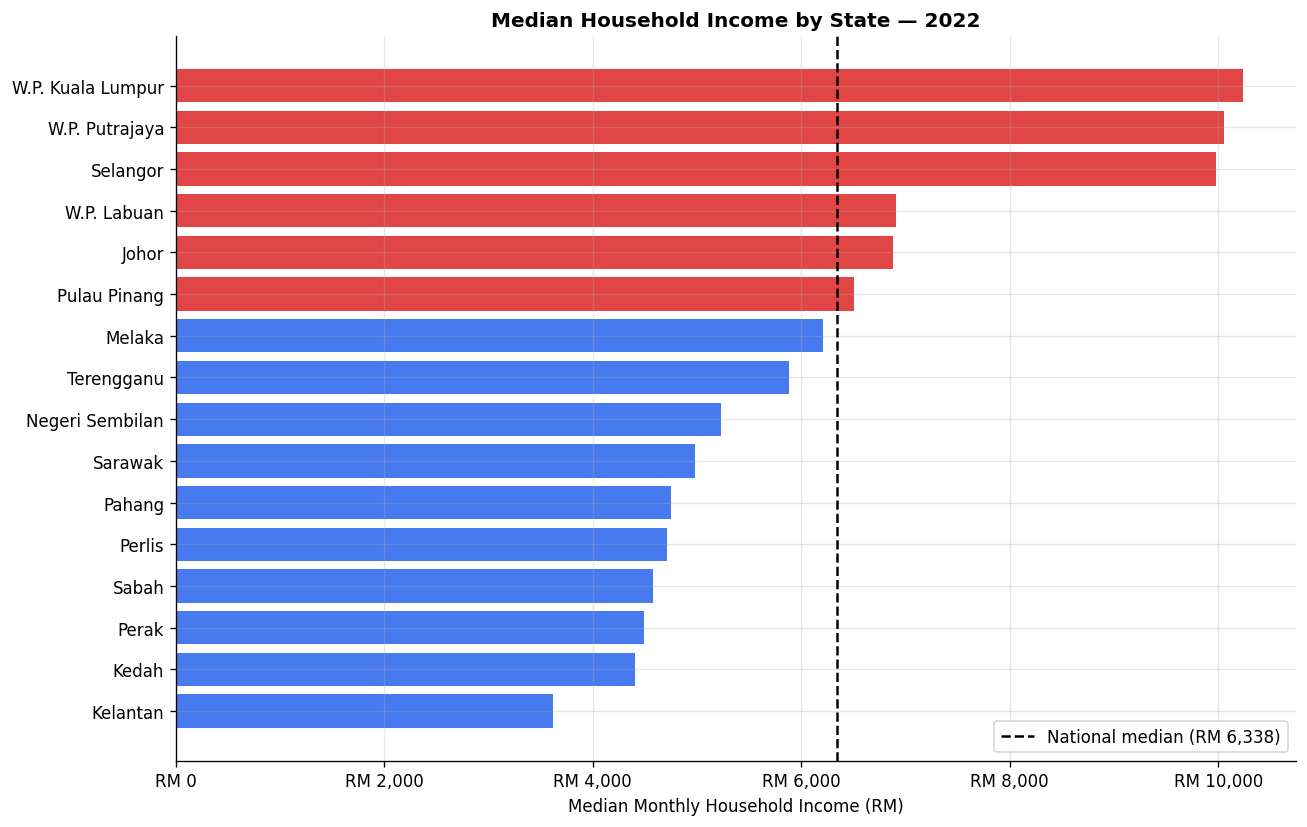


Highest: W.P. Kuala Lumpur — RM 10,234
Lowest:  Kelantan  — RM 3,614
Ratio:   2.83×


In [15]:
# ── D2: Household income by state — regional inequality ──────────────
# Latest HIES year
latest_hies = hh_state['date'].max()
hh_latest = hh_state[hh_state['date'] == latest_hies].sort_values('income_median', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [RED if v > hh_nat[hh_nat['date']==latest_hies]['income_median'].values[0]
          else BLUE for v in hh_latest['income_median']]
bars = ax.barh(hh_latest['state'], hh_latest['income_median'], color=colors, alpha=0.85)

nat_median = hh_nat[hh_nat['date']==latest_hies]['income_median'].values[0]
ax.axvline(nat_median, color='black', linewidth=1.5, linestyle='--',
           label=f'National median (RM {nat_median:,})')
ax.set_xlabel('Median Monthly Household Income (RM)')
ax.set_title(f'Median Household Income by State — {latest_hies.year}', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"\nHighest: {hh_latest.iloc[-1]['state']} — RM {hh_latest.iloc[-1]['income_median']:,}")
print(f"Lowest:  {hh_latest.iloc[0]['state']}  — RM {hh_latest.iloc[0]['income_median']:,}")
print(f"Ratio:   {hh_latest.iloc[-1]['income_median'] / hh_latest.iloc[0]['income_median']:.2f}×")


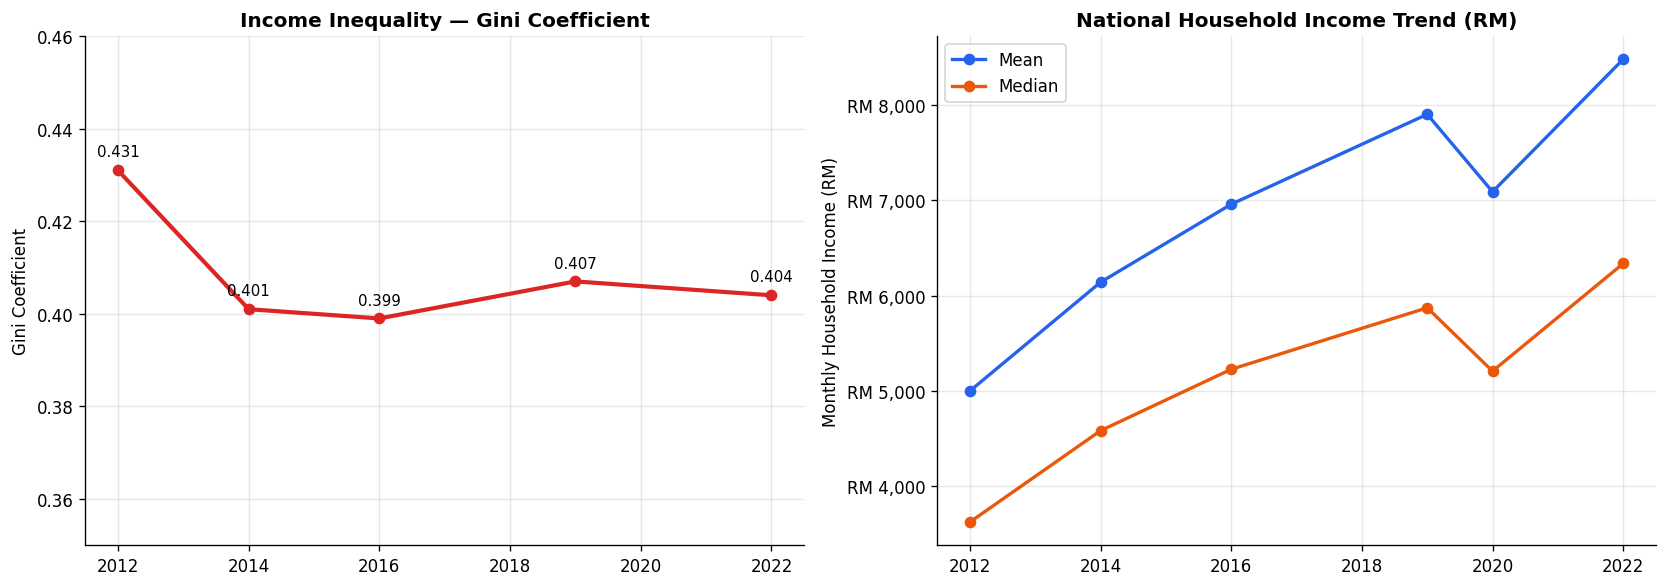

In [16]:
# ── D3: Gini coefficient + household income trend ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gini['date'], gini['gini'], marker='o', color=RED, linewidth=2.5)
axes[0].set_title('Income Inequality — Gini Coefficient', fontweight='bold')
axes[0].set_ylabel('Gini Coefficient')
axes[0].set_ylim(0.35, 0.46)
for _, row in gini.iterrows():
    axes[0].text(row['date'], row['gini'] + 0.003, f"{row['gini']:.3f}", ha='center', fontsize=9)

axes[1].plot(hh_nat['date'], hh_nat['income_mean'],   marker='o', color=BLUE,   label='Mean',   linewidth=2)
axes[1].plot(hh_nat['date'], hh_nat['income_median'], marker='o', color=ORANGE, label='Median', linewidth=2)
axes[1].set_title('National Household Income Trend (RM)', fontweight='bold')
axes[1].set_ylabel('Monthly Household Income (RM)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 🌏 E. ASEAN Benchmarking

**Data:** `asean_comparison.csv`
**Key question:** How does Malaysia's education investment and graduate labour market compare to ASEAN peers?


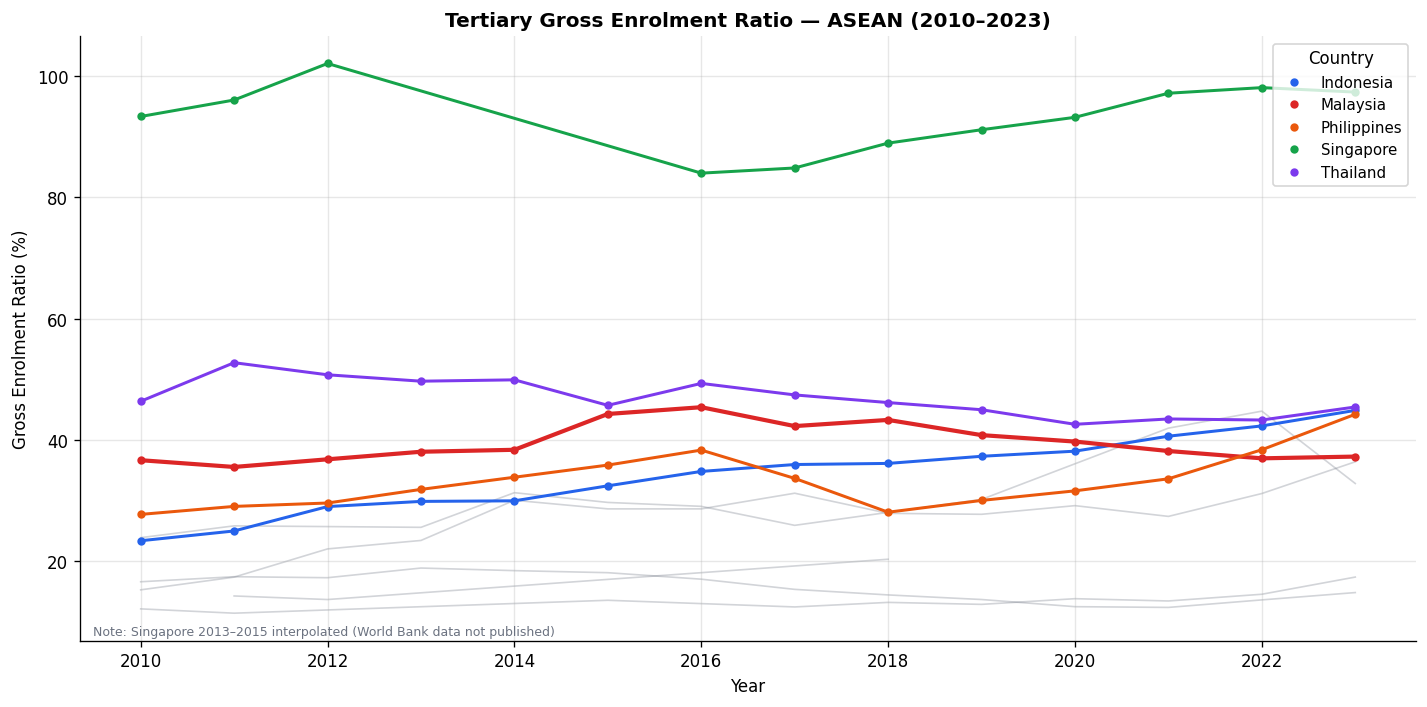

In [17]:
# Explicit colors so Malaysia (red) is never confused with Thailand
HIGHLIGHT_COLORS = {
    'Malaysia':    '#DC2626',   # red
    'Singapore':   '#16A34A',   # green
    'Thailand':    '#7C3AED',   # purple
    'Indonesia':   '#2563EB',   # blue
    'Philippines': '#EA580C',   # orange
}

asean_pivot = asean.pivot_table(index='year', columns='country',
                                values='tertiary_gross_enrolment_ratio')

# Interpolate missing years within each country series so lines connect across
# World Bank data gaps (e.g. Singapore 2013-2015 not published)
# interpolate(limit_area='inside') only fills interior gaps, never extrapolates
asean_pivot_filled = asean_pivot.interpolate(method='linear', limit_area='inside')

fig, ax = plt.subplots(figsize=(12, 6))
for country in asean_pivot_filled.columns:
    if country in HIGHLIGHT_COLORS:
        lw = 2.5 if country == 'Malaysia' else 1.8
        # Plot interpolated line (no markers on interpolated gaps)
        ax.plot(asean_pivot_filled.index, asean_pivot_filled[country],
                color=HIGHLIGHT_COLORS[country], linewidth=lw,
                linestyle='-', zorder=3)
        # Plot actual data points as markers on top
        actual = asean_pivot[country].dropna()
        ax.plot(actual.index, actual.values,
                label=country, color=HIGHLIGHT_COLORS[country],
                marker='o', markersize=4, linewidth=0, zorder=4)
    else:
        ax.plot(asean_pivot_filled.index, asean_pivot_filled[country],
                color=GRAY, alpha=0.3, linewidth=1, zorder=1)

ax.set_title('Tertiary Gross Enrolment Ratio — ASEAN (2010–2023)', fontweight='bold')
ax.set_ylabel('Gross Enrolment Ratio (%)')
ax.set_xlabel('Year')
ax.legend(fontsize=9, title='Country')
# Note on interpolation
ax.annotate('Note: Singapore 2013–2015 interpolated (World Bank data not published)',
            xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7.5, color=GRAY)
plt.tight_layout()
plt.show()

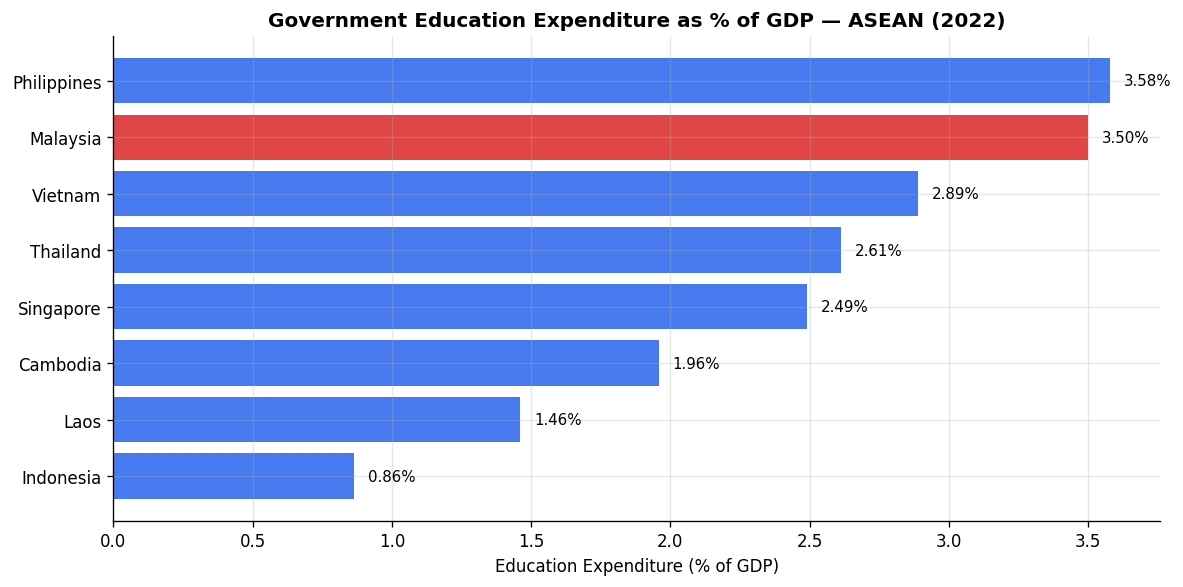

In [18]:
# ── E2: Education expenditure % GDP ──────────────────────────────────
latest_asean = asean[asean['year'] == 2022].dropna(subset=['education_expenditure_pct_gdp'])
latest_asean = latest_asean.sort_values('education_expenditure_pct_gdp', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if c == 'Malaysia' else BLUE for c in latest_asean['country']]
bars = ax.barh(latest_asean['country'], latest_asean['education_expenditure_pct_gdp'],
               color=colors, alpha=0.85)
ax.set_xlabel('Education Expenditure (% of GDP)')
ax.set_title('Government Education Expenditure as % of GDP — ASEAN (2022)', fontweight='bold')
for bar, val in zip(bars, latest_asean['education_expenditure_pct_gdp']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


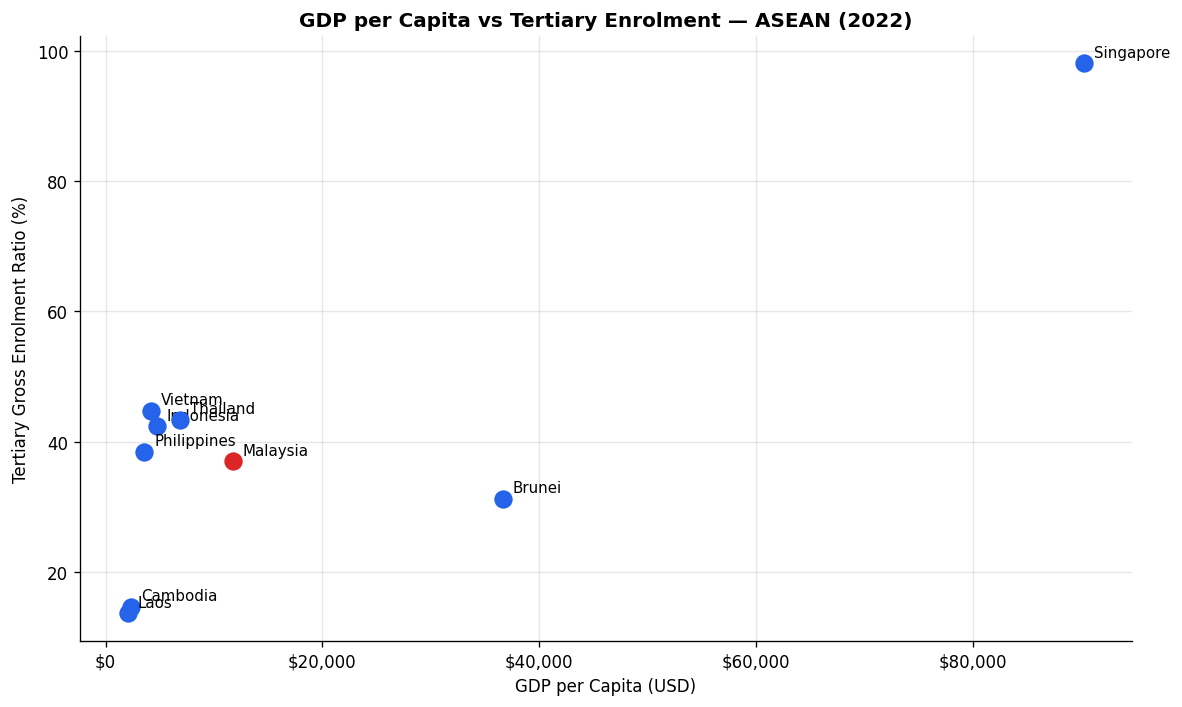

In [19]:
# ── E3: GDP per capita vs tertiary enrolment scatter ─────────────────
asean_2022 = asean[asean['year'] == 2022].dropna(
    subset=['gdp_per_capita_usd', 'tertiary_gross_enrolment_ratio'])

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in asean_2022.iterrows():
    color = RED if row['country'] == 'Malaysia' else BLUE
    ax.scatter(row['gdp_per_capita_usd'], row['tertiary_gross_enrolment_ratio'],
               s=100, color=color, zorder=3)
    ax.annotate(row['country'],
                (row['gdp_per_capita_usd'], row['tertiary_gross_enrolment_ratio']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Tertiary Gross Enrolment Ratio (%)')
ax.set_title('GDP per Capita vs Tertiary Enrolment — ASEAN (2022)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


---
## 📝 EDA Summary — Key Findings

| # | Finding | Implication |
|---|---|---|
| A1 | Medicine & Engineering have the highest fees; Education & Science the lowest | Field choice dramatically changes cost exposure |
| A2 | Private fees are 9–15× higher than public for legally equivalent degrees | Institution type is the single biggest cost driver |
| B1 | Education CPI has risen faster than overall CPI since 2010 | Real cost of a degree is increasing beyond general inflation |
| B2 | Real household income growth has not kept pace with education cost inflation | Affordability is worsening, especially for lower-income households |
| C1 | Young graduates (15–24) have SRU rates above 60% — over 3× the rate of older workers | Fresh graduates are most at risk of underemployment |
| C2 | Female graduates have consistently higher SRU rates than males | Gender gap in job quality persists beyond participation |
| C3 | Youth unemployment is 3–4× higher than overall unemployment | Transition into the labour market remains the critical risk period |
| D1 | Female labour force participation is ~17 pp lower than male | Structural gap reduces the measurable financial return of a degree for women |
| D2 | KL/Putrajaya median income is 2–3× rural states | Geography compounds the degree ROI gap |
| E1 | Malaysia's tertiary enrolment ratio is mid-range for ASEAN | Supply of graduates is growing without proportional labour market absorption |
| E2 | Malaysia spends ~3.5–5% of GDP on education — above regional average | High public spending but declining measurable returns |

> **Next step:** `03_analysis.ipynb` — translate these findings into the cost-squeeze narrative and ROI framework.
